In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

This document is based on `logistic_regression_centralized_one_complication`, where a centralized logistic regression model is trained for a single complication.

To evaluate all four complications, we add a wrapper function that runs the training and evaluation pipeline once for each complication:

- Alveolar Osteitis
- Secondary Infection
- Nerve Dysesthesia
- Bleeding

For each complication, a separate logistic regression model is trained on the full centralized dataset.
The wrapper stores the final F1-score for each complication. To obtain a single performance measure, we compute the average of the four macro F1-scores:

$$
F1_{\text{overall}}
=
\frac{1}{4}
\sum_{c=1}^{4}
F1_c,
$$


## Data

In [2]:
path_train = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
path_test = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"

df = pd.read_csv(path_train)
test_data = pd.read_csv(path_test)

variables = df.columns[2:27].tolist()

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

client_col = "Client"

scaler = StandardScaler()

train_design = pd.DataFrame(
    scaler.fit_transform(df[variables]),
    columns=variables,
    index=df.index
)

test_design = pd.DataFrame(
    scaler.transform(test_data[variables]),
    columns=variables,
    index=test_data.index
)

for complication in complications:
    category_col = complication.replace("Risk_", "Risk_Category_", 1)

    train_design[complication] = df[complication].values
    train_design[category_col] = df[category_col].values

    test_design[complication] = test_data[complication].values
    test_design[category_col] = test_data[category_col].values

train_design[client_col] = df[client_col].values

## Functions

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def assign_tertiles(y_hat):
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2


def metrics_for_one_complication(y_true, y_pred):
    results = {}

    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])

    return {
        "per_class": results,
        "macro_f1": macro_f1
    }


def centralized_logistic_regression_binary(
    train_df,
    test_df,
    variables,
    target_col,
    category_col,
    epochs=50,
    lr=0.001,
    random_state=42
):
    X_train = train_df[variables].to_numpy(dtype=float)
    y_train = train_df[target_col].to_numpy(dtype=int)

    X_test = test_df[variables].to_numpy(dtype=float)
    y_true_group = test_df[category_col].to_numpy(dtype=int)

    model = SGDClassifier(
        loss="log_loss",
        penalty=None,
        learning_rate="constant",
        eta0=lr,
        max_iter=1,
        tol=None,
        warm_start=True,
        random_state=random_state
    )

    history = []

    # Initialisering
    model.partial_fit(
        X_train[:1],
        y_train[:1],
        classes=np.array([0, 1])
    )

    for epoch in range(epochs):

        old_coef = model.coef_.copy()
        old_intercept = model.intercept_.copy()

        # Én epoch på samlet data
        model.partial_fit(X_train, y_train)

        coef_change = np.linalg.norm(model.coef_ - old_coef)
        intercept_change = np.linalg.norm(model.intercept_ - old_intercept)

        logits = X_test @ model.coef_.T + model.intercept_
        probs = sigmoid(logits).ravel()

        y_pred_group, q1, q2 = assign_tertiles(probs)

        metrics = metrics_for_one_complication(y_true_group, y_pred_group)
        macro_f1 = metrics["macro_f1"]

        history.append({
            "epoch": epoch + 1,
            "macro_f1": macro_f1,
            "q1": q1,
            "q2": q2,
            "coef_change": coef_change,
            "intercept_change": intercept_change
        })

        print(
            f"Epoch {epoch+1:03d} | Macro F1 = {macro_f1:.4f} | "
            f"coef_change = {coef_change:.6f} | "
            f"intercept_change = {intercept_change:.6f}"
        )

    return model.intercept_, model.coef_, pd.DataFrame(history)

def run_all_centralized_logistic_complications(
    train_df,
    test_df,
    variables,
    complications,
    epochs=50,
    lr=0.001,
    random_state=42
):
    results = {}
    models = {}
    macro_f1s = []

    for complication in complications:
        category_col = complication.replace("Risk_", "Risk_Category_", 1)

        print("\n==============================")
        print(f"Running {complication}")
        print("==============================")

        intercept, coef, history = centralized_logistic_regression_binary(
            train_df=train_df,
            test_df=test_df,
            variables=variables,
            target_col=complication,
            category_col=category_col,
            epochs=epochs,
            lr=lr,
            random_state=random_state
        )

        final_f1 = history["macro_f1"].iloc[-1]

        results[complication] = {
            "history": history,
            "final_macro_f1": final_f1
        }

        models[complication] = {
            "intercept": intercept,
            "coef": coef
        }

        macro_f1s.append(final_f1)

    overall_macro_f1 = np.mean(macro_f1s)

    return {
        "models": models,
        "results": results,
        "overall_macro_f1": overall_macro_f1
    }

## Traning

In [4]:
complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

centralized_logistic_output = run_all_centralized_logistic_complications(
    train_df=train_design,
    test_df=test_design,
    variables=variables,
    complications=complications,
    epochs=50,
    lr=0.001,
    random_state=42
)

print("\n==============================")
print(f"CENTRALIZED LOGISTIC FINAL F1 = {centralized_logistic_output['overall_macro_f1']:.3f}")
print("==============================")


Running Risk_AlveolarOsteitis
Epoch 001 | Macro F1 = 0.6666 | coef_change = 0.595054 | intercept_change = 2.407575
Epoch 002 | Macro F1 = 0.6682 | coef_change = 0.086502 | intercept_change = 0.087112
Epoch 003 | Macro F1 = 0.6696 | coef_change = 0.015400 | intercept_change = 0.013357
Epoch 004 | Macro F1 = 0.6696 | coef_change = 0.002844 | intercept_change = 0.002367
Epoch 005 | Macro F1 = 0.6696 | coef_change = 0.000526 | intercept_change = 0.000433
Epoch 006 | Macro F1 = 0.6696 | coef_change = 0.000097 | intercept_change = 0.000080
Epoch 007 | Macro F1 = 0.6696 | coef_change = 0.000018 | intercept_change = 0.000015
Epoch 008 | Macro F1 = 0.6696 | coef_change = 0.000003 | intercept_change = 0.000003
Epoch 009 | Macro F1 = 0.6696 | coef_change = 0.000001 | intercept_change = 0.000001
Epoch 010 | Macro F1 = 0.6696 | coef_change = 0.000000 | intercept_change = 0.000000
Epoch 011 | Macro F1 = 0.6696 | coef_change = 0.000000 | intercept_change = 0.000000
Epoch 012 | Macro F1 = 0.6696 | co

### Individual Metrics

In [5]:
for complication, res in centralized_logistic_output["results"].items():
    print(f"{complication}: {res['final_macro_f1']:.3f}")

Risk_AlveolarOsteitis: 0.670
Risk_SecondaryInfection: 0.682
Risk_NerveDysesthesia: 0.727
Risk_Bleeding: 0.528


### Coefficient Plot

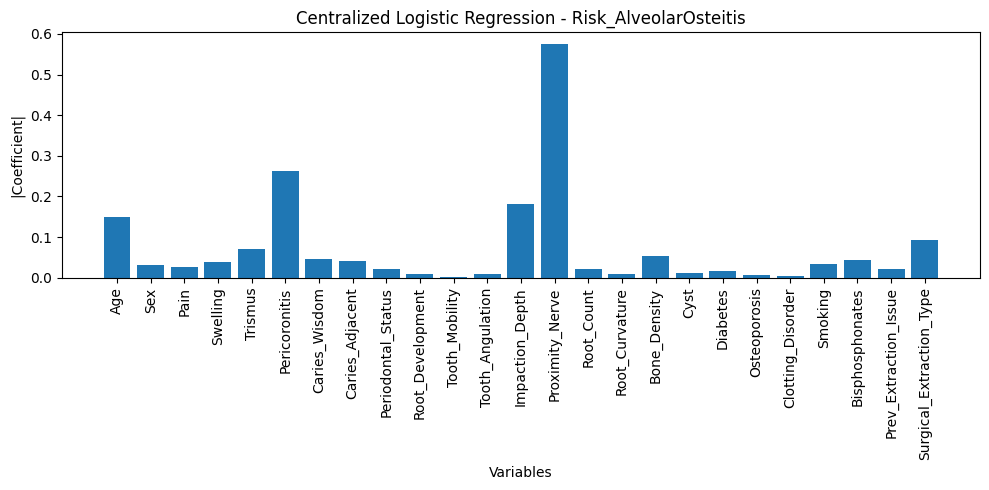

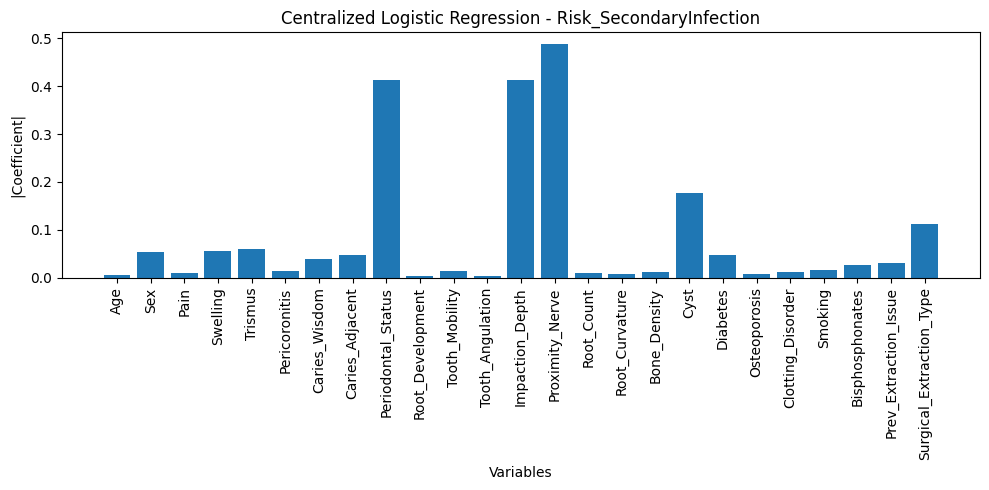

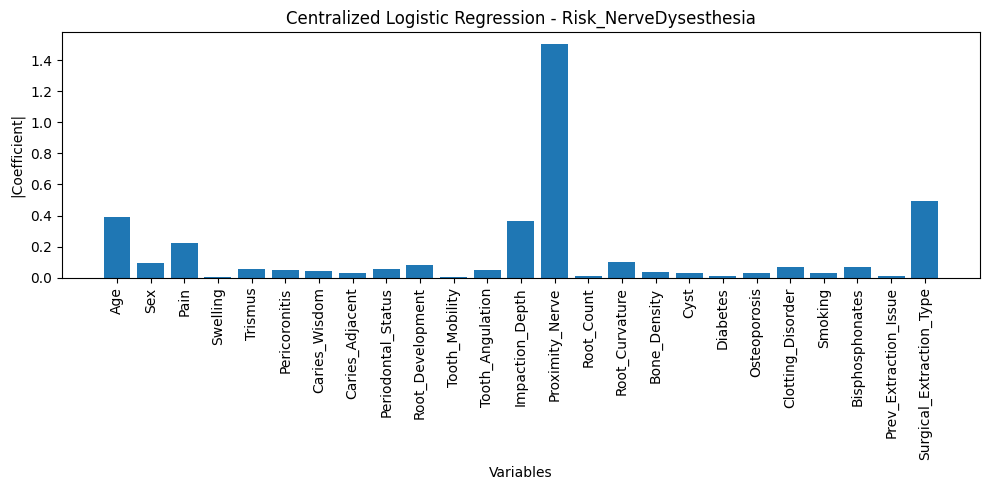

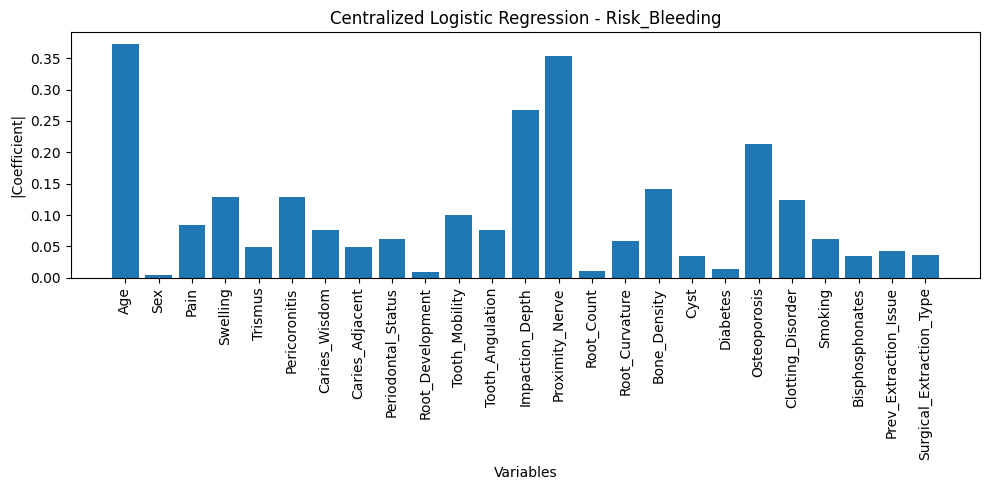

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_logistic_magnitude(coefs, variable_names, title):
    
    coefs = np.asarray(coefs).flatten()

    fig, ax = plt.subplots(figsize=(10, 5))

    magnitudes = np.abs(coefs)

    ax.bar(range(len(coefs)), magnitudes)

    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)

    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")

    plt.tight_layout()
    plt.show()

def plot_all_centralized_logistic_complications(models, variables):

    for complication, model_dict in models.items():

        plot_logistic_magnitude(
            model_dict["coef"],
            variables,
            title=f"Centralized Logistic Regression - {complication}"
        )

plot_all_centralized_logistic_complications(
    centralized_logistic_output["models"],
    variables
)